# GardenSewa Yearly Services Analysis

## 1. Introduction

This report analyzes the yearly demand pattern for GardenSewa's **20 gardening and landscaping services**. Each service is rated on a monthly demand scale of Low, Medium, or High, based on Nepal's climate cycle (pre monsoon, monsoon, post monsoon, and winter) and major festivals such as Dashain and Tihar.

The goal of this analysis is to understand:
- How demand shifts across the year for each service
- Which months see the most High demand services
- How demand patterns differ across service categories
- Which categories stay busy for the longest stretch of the year

The following sections walk through the dataset, present four visualizations, and close with a set of key findings.

## 2. Setup

In [1]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('future.no_silent_downcasting', True)

In [2]:
# Loading the dataset
df = pd.read_excel("Yearly_Services.xlsx")
df.columns = df.columns.str.strip()
print(df.columns.tolist(), "\n")
print(df.head())

['#', 'Service Name', 'Category', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Peak Season', 'Remarks'] 

   #                Service Name                         Category Jan Feb Mar  \
0  1                   Lawn Care                    Lawn and Turf   L   L   M   
1  2  Planting and Transplanting                Planting Services   M   M   H   
2  3          Garden Maintenance                      Garden Care   M   M   M   
3  4            Soil Improvement           Soil and Fertilization   L   M   H   
4  5         Irrigation Services  Irrigation and Water Management   L   M   H   

  Apr May Jun Jul Aug Sep Oct Nov Dec         Peak Season  \
0   H   H   H   H   M   M   M   L   L  Apr, May, Jun, Jul   
1   H   M   L   L   L   M   H   M   L       Mar, Apr, Oct   
2   H   H   M   M   M   H   H   M   M  Apr, May, Sep, Oct   
3   H   M   L   L   L   M   H   M   L       Mar, Apr, Oct   
4   H   H   M   L   L   M   M   L   L       Mar, Apr, May   



## 3. Data Overview

In [3]:
# Structural Summary
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   #             20 non-null     int64 
 1   Service Name  20 non-null     object
 2   Category      20 non-null     object
 3   Jan           20 non-null     object
 4   Feb           20 non-null     object
 5   Mar           20 non-null     object
 6   Apr           20 non-null     object
 7   May           20 non-null     object
 8   Jun           20 non-null     object
 9   Jul           20 non-null     object
 10  Aug           20 non-null     object
 11  Sep           20 non-null     object
 12  Oct           20 non-null     object
 13  Nov           20 non-null     object
 14  Dec           20 non-null     object
 15  Peak Season   20 non-null     object
 16  Remarks       20 non-null     object
dtypes: int64(1), object(16)
memory usage: 2.8+ KB
None


In [4]:
# Total services and category breakdown
print(f"Total services: {len(df)}", "\n")
print(df["Category"].value_counts())

Total services: 20 

Category
Specialty Gardening                3
Lawn and Turf                      2
Planting Services                  2
Garden Care                        2
Soil and Fertilization             2
Hardscaping and Construction       2
Design and Consultation            2
Tree Services                      2
Irrigation and Water Management    1
Plant Health Management            1
Seasonal and Festive               1
Name: count, dtype: int64


In [5]:
# Monthly High, Medium, Low counts
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
for m in months:
    print(m, dict(df[m].value_counts()))

Jan {'L': np.int64(11), 'M': np.int64(9)}
Feb {'M': np.int64(11), 'L': np.int64(5), 'H': np.int64(4)}
Mar {'H': np.int64(12), 'M': np.int64(8)}
Apr {'H': np.int64(15), 'M': np.int64(5)}
May {'M': np.int64(9), 'H': np.int64(7), 'L': np.int64(4)}
Jun {'L': np.int64(11), 'M': np.int64(6), 'H': np.int64(3)}
Jul {'L': np.int64(15), 'M': np.int64(3), 'H': np.int64(2)}
Aug {'L': np.int64(14), 'M': np.int64(6)}
Sep {'M': np.int64(16), 'H': np.int64(4)}
Oct {'H': np.int64(12), 'M': np.int64(7), 'L': np.int64(1)}
Nov {'M': np.int64(8), 'L': np.int64(7), 'H': np.int64(5)}
Dec {'L': np.int64(13), 'M': np.int64(7)}


**Insight:** The dataset covers **20 services** spread across **11 categories**. Most categories hold two services each, while Speciality Gardening has three, and three categories: Irrigation and Water Management, Plant Health Management, and Seasonal and Festive, have only one each. Looking at all the 240 monthly demand ratings across the year, Medium demand is the most common at 95 ratings, followed by Low at 81 ratings and High at 64 ratings. This shows that most services stay moderately busy through the year rather than swinging sharply between quiet and peak periods. 

## 4. Visual Analysis
### Chart 1 - Monthly Demand Distribution Across All 20 Services

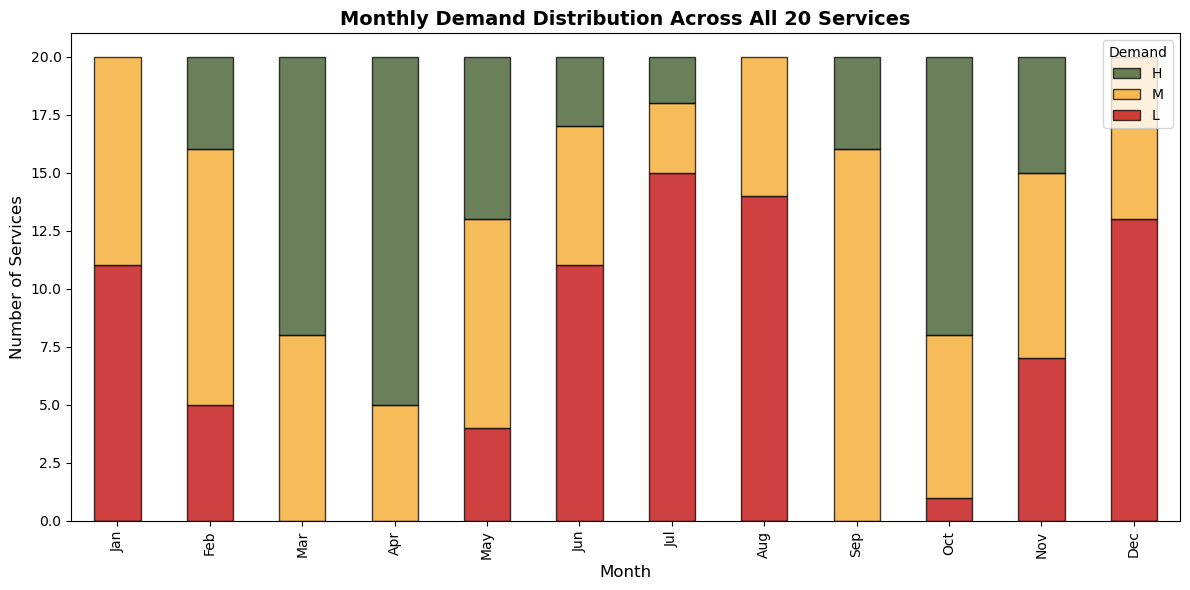

In [6]:
counts = df[months].apply(pd.Series.value_counts).fillna(0).reindex(["L","M","H"]).T

ax = counts.plot(kind="bar", stacked=True, figsize=(12,6), color=["#C00000","#F5A623","#375623"], edgecolor="black", alpha=0.75)

h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], title="Demand")
plt.title("Monthly Demand Distribution Across All 20 Services", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Services", fontsize=12)
plt.tight_layout()
plt.savefig("chart1.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** April is the single busiest month, with 15 of the 20 services rated High demand, followed by March and October, tied at 12 each. January, August, and December have no High demand services at all, showing that the depth of winter and the wettest stretch of monsoon are the quietest periods for gardening work. This pattern lines up closely with Nepal's pre monsoon planting window and the dry, festival heavy months of the post monsoon season.

### Chart 2 - Monthly Demand Heat Map for All 20 Services

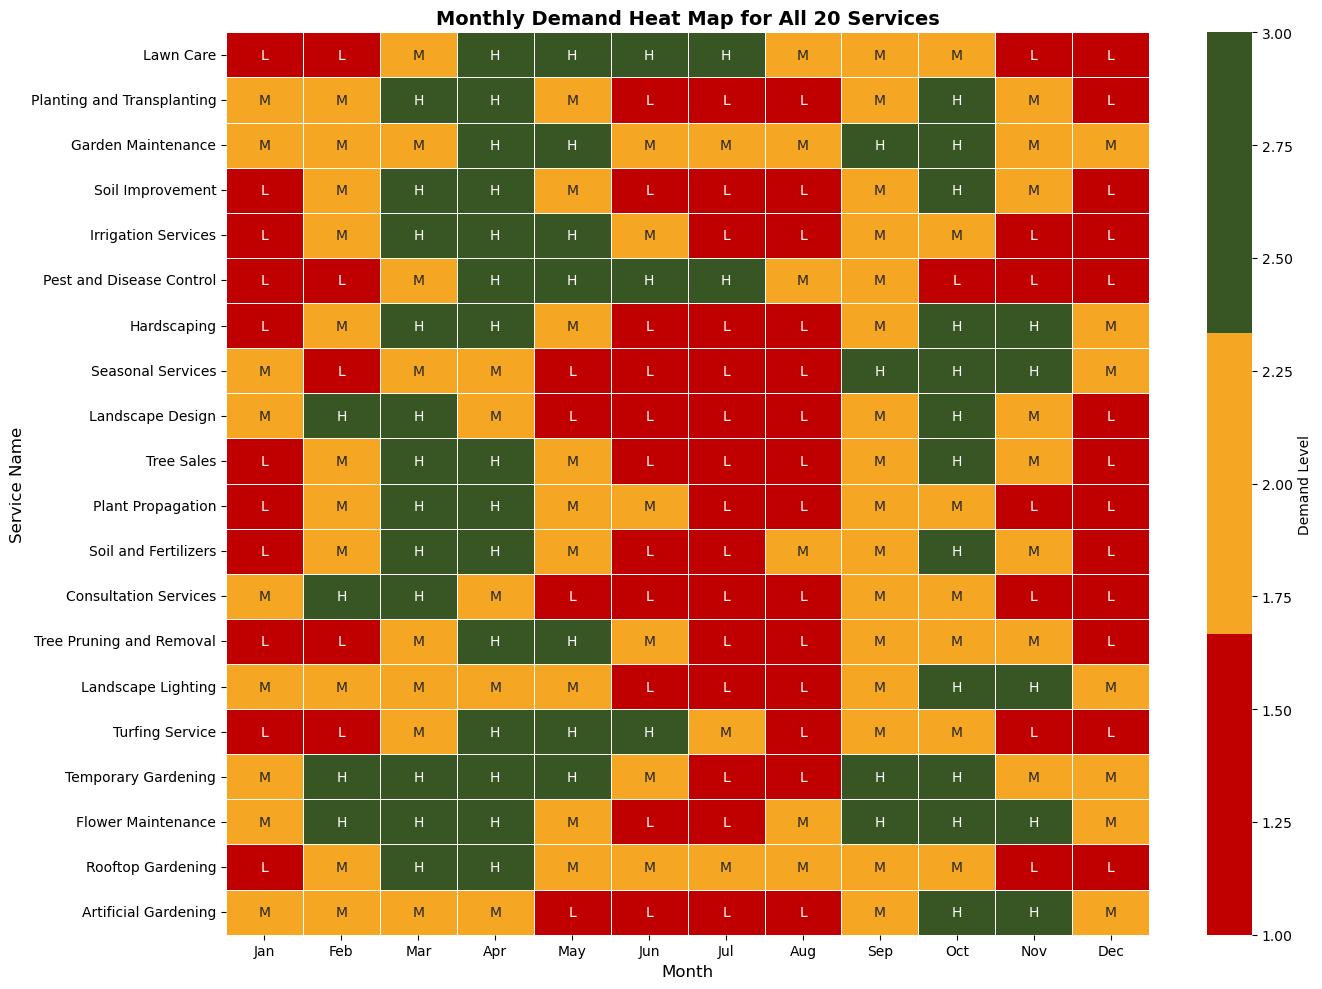

In [7]:
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
demand_map = {"H": 3, "M": 2, "L": 1}

letters = df.set_index("Service Name")[months]
heat_df = letters.replace(demand_map).astype(float)

plt.figure(figsize=(14,10))
sns.heatmap(heat_df, annot=letters, fmt="", cmap=["#C00000","#F5A623","#375623"], 
            linewidth=0.5, linecolor="white", cbar_kws={"label": "Demand Level"})

plt.title("Monthly Demand Heat Map for All 20 Services", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Service Name", fontsize=12)
plt.tight_layout()
plt.savefig("chart2.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Most services follow a similar shape, rising through the pre monsoon months of March and April, dropping through the wet core of monsoon from June to August, and picking up again in September and October ahead of the festival season. Lawn Care and Pest and Disease Control show the clearest four month High demand stretch, from April through July. Seasonal Services stands out as an exception, staying High from September through November, which lines up with the Dashain and Tihar festival period rather than following the weather pattern seen elsewhere. Landscape Lighting follows a similar pattern but a month later, peaking only in October and November.

### Chart 3 - Service Count and Average Peak Months by Category

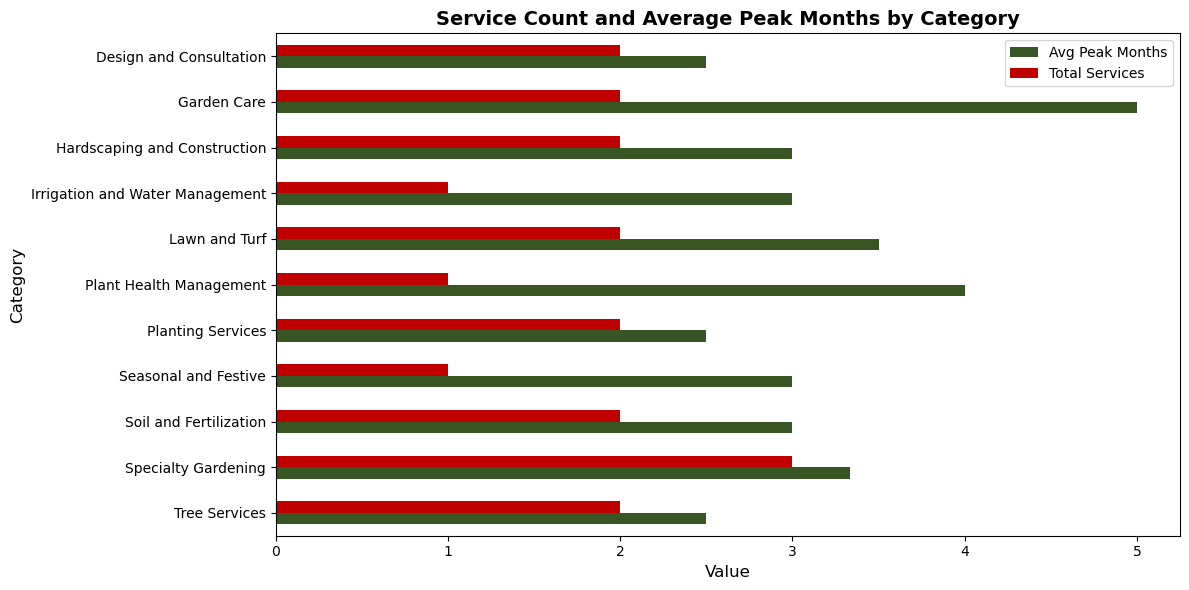

                                 Avg Peak Months  Total Services
Category                                                        
Garden Care                             5.000000               2
Plant Health Management                 4.000000               1
Lawn and Turf                           3.500000               2
Specialty Gardening                     3.333333               3
Hardscaping and Construction            3.000000               2
Irrigation and Water Management         3.000000               1
Seasonal and Festive                    3.000000               1
Soil and Fertilization                  3.000000               2
Design and Consultation                 2.500000               2
Planting Services                       2.500000               2
Tree Services                           2.500000               2


In [8]:
df["Peak Months"] = (df[months] == "H").sum(axis=1)
cat_df = df.groupby("Category").agg(**{"Avg Peak Months": ("Peak Months","mean"),
                                   "Total Services": ("Service Name","count")})

ax = cat_df.iloc[::-1].plot(kind="barh", figsize=(12,6), color=["#375623","#C00000"])
plt.title("Service Count and Average Peak Months by Category", fontsize=14, fontweight="bold")
plt.xlabel("Value", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.tight_layout()
plt.savefig("chart3.png", dpi=150, bbox_inches="tight")
plt.show()

print(cat_df.sort_values("Avg Peak Months", ascending=False))

**Insight:** Garden Care has the longest average High demand stretch at 5 months per service, the highest of any category. Design and Consultation, Planting Services, and Tree Services have the shortest average High demand window at 2.5 months each, meaning these services see sharper, shorter seasonal spikes rather than a long stretch of steady demand. Specialty Gardening is the largest category with three services, though its average High demand window of about 3.3 months sits closer to the middle of the group.

### Chart 4 - Seasonal Demand Trend by Service Category

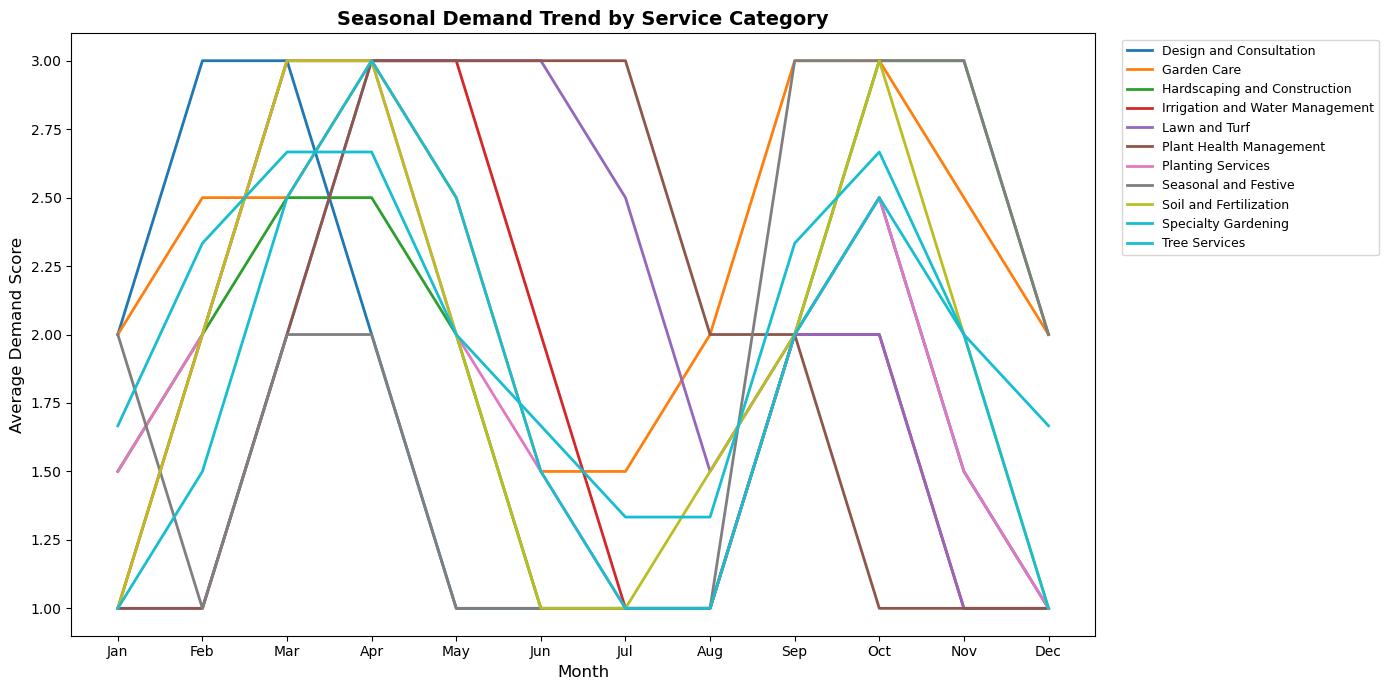

Category
Garden Care                        2.333333
Specialty Gardening                2.027778
Hardscaping and Construction       1.958333
Lawn and Turf                      1.916667
Plant Health Management            1.916667
Soil and Fertilization                1.875
Irrigation and Water Management    1.833333
Planting Services                  1.833333
Seasonal and Festive               1.833333
Tree Services                      1.791667
Design and Consultation                1.75
dtype: object

In [9]:
demand_map = {"H": 3, "M": 2, "L": 1}
cat_month = df[months].replace(demand_map).groupby(df["Category"]).mean().T

ax = cat_month.plot(figsize=(14,7), colormap="tab10", linewidth=2)
plt.title("Seasonal Demand Trend by Service Category", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Demand Score", fontsize=12)
plt.xticks(range(12), months)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("chart4.png", dpi=150, bbox_inches="tight")
plt.show()

cat_month.mean(axis=0).sort_values(ascending=False)

**Insight:** Garden Care and Specialty Gardening have the highest average demand scores across the year (2.33 and 2.03), because they stay consistently mid to high without dropping to the seasonal lows that categories like Plant Health Management or Seasonal and Festive experience. Those two swing between 3.0 and 1.0 several times, which pulls their yearly average down despite hitting the ceiling more often. Irrigation and Water Management shows the sharpest single season spike, climbing to its highest score during the pre monsoon stretch from March through May, before dropping off once the monsoon rains take over natural watering. Lawn and Turf follows a similar pattern but a month later, peaking from April through June before the summer heat and heavy monsoon rain set in. Design and Consultation peaks earliest in the year, in February and March, since planning work has to happen before the physical construction season begins.

## 5. Key Findings

1. **April is the peak month for GardenSewa services:** 15 of the 20 services are rated High demand in April, the single busiest month of the year, driven by the pre monsoon planting and construction window.

2. **Winter and peak monsoon are the quiet months:** January, August, and December have zero services rated High demand, showing that the coldest part of winter and the wettest stretch of monsoon slow down most gardening activity.

3. **Demand ratings lean toward Medium overall:** Out of 240 monthly ratings across the year, Medium demand accounts for 95, Low for 81, and High for only 64, meaning most services stay moderately active rather than swinging between extremes.

4. **Garden Care has the longest busy season:** With an average High demand window of 5 months per service, Garden Care, made up of Garden Maintenance and Flower Maintenance, stays busy longer than any other category. This is driven mainly by Flower Maintenance, which holds High demand for 6 of the 12 months around the festival season.

5. **Festival timing drives a second demand wave:** Services like Seasonal Services and Landscape Lighting break from the weather driven pattern seen elsewhere, peaking around Dashain and Tihar. Seasonal Services runs High from September through November, while Landscape Lighting peaks a month later, in October and November.

6. **Some categories have short, sharp peaks:** Design and Consultation, Planting Services, and Tree Services average just 2.5 High demand months each, suggesting these services see brief, concentrated rushes rather than extended busy periods.

### Overall Takeaway
GardenSewa's yearly demand follows Nepal's climate and festival calendar closely. The pre monsoon window of March and April is the busiest stretch for most services, monsoon and deep winter are the quietest, and a second wave of festival driven demand lifts a handful of services again between September and November. This pattern can help GardenSewa plan staffing, marketing, and inventory around the months that matter most for each service category.